# Euclidean Distance


In [4]:
import numpy as np

# Function to compute Euclidean Distance.


def euclidean(v1, v2):

    # Convert 1-D Python lists to numpy vectors, calc garna ni sajilo huncha
    # more faster ani efficient

    v1 = np.array(v1)
    v2 = np.array(v2)

    # Compute vector which is the element wise square of the difference
    return np.linalg.norm(v1-v2)

In [5]:
# Define 3 users with ratings for 5 movies

u1 = [5, 1, 2, 4, 5]
u2 = [1, 5, 4, 2, 1]
u3 = [5, 2, 2, 4, 4]

In [6]:
euclidean(u1, u2)

np.float64(7.483314773547883)

In [7]:
euclidean(u1, u3)

np.float64(1.4142135623730951)

In [8]:
euclidean(u2, u3)

np.float64(6.48074069840786)

# Pearson Correlation

In [ ]:
from scipy.stats import pearsonr

alice = [1, 1, 3, 2, 4]
bob = [2, 2, 4, 3, 5]
eve = [5, 5, 3, 4, 2]

print(pearsonr(alice, bob))  # highest possible similarity score
print(pearsonr(alice, eve))  # lowest possible score
print(pearsonr(bob, eve))

PearsonRResult(statistic=np.float64(1.0), pvalue=np.float64(0.0))
PearsonRResult(statistic=np.float64(-1.0), pvalue=np.float64(0.0))
PearsonRResult(statistic=np.float64(-1.0), pvalue=np.float64(0.0))


# K-Means Clustering


In [22]:
!pip install matplotlib
!pip install seaborn



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


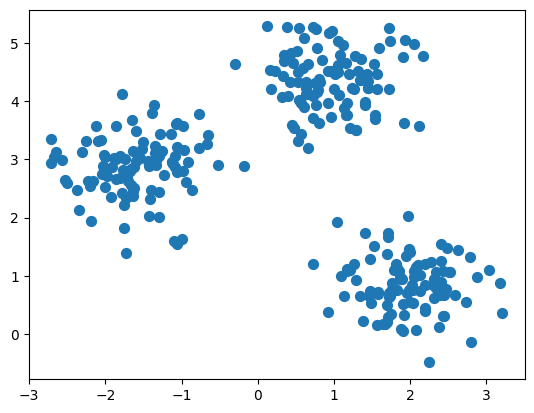

In [23]:
# Import the function that enables us to plot clusters
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
# Get points such that they form 3 visually separable clusters

X, y = make_blobs(n_samples=300, centers=3, cluster_std=0.50, random_state=0)

# Plot the points on scatterplot
plt.scatter(X[:, 0], X[:, 1], s=50)

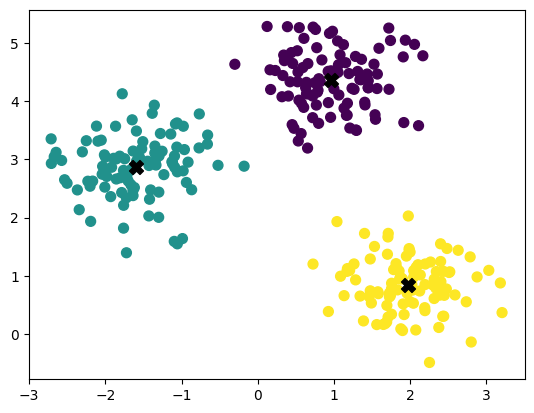

In [24]:
# Import the K-Means class
from sklearn.cluster import KMeans

# Initialize the K-Means object. Set number of cluster to 3,
# Centroid initialization as 'random' and maximum iterations to 10
kmeans = KMeans(n_clusters=3, init='random', max_iter=10)

# Compute the K-Means clustering
kmeans.fit(X)

# Predict the classes for every point
y_pred = kmeans.predict(X)

# Plot the data points again but with different colors for different classes
plt.scatter(X[:, 0], X[:, 1], c=y_pred, s=50)

# Get the list of the final centroids
centroids = kmeans.cluster_centers_

# Plot the centroids onto the same scatterplot.
plt.scatter(centroids[:, 0], centroids[:, 1], c='black', s=100, marker='X')

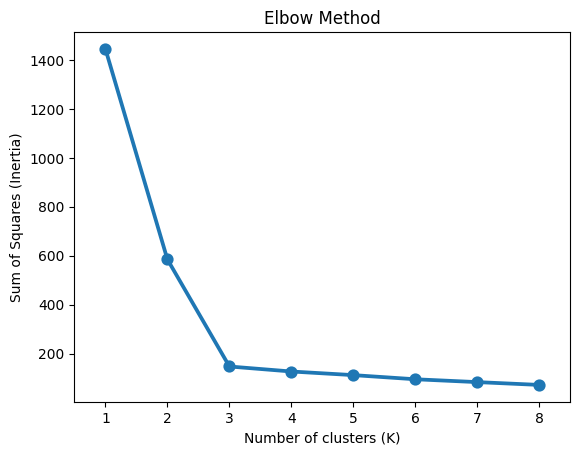

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# List to hold sum-of-squares
ss = []

# Compute SS for cluster sizes 1 to 8
for i in range(1, 9):
    kmeans = KMeans(n_clusters=i, random_state=0,
                    max_iter=10, init='random').fit(X)
    ss.append(kmeans.inertia_)

# Plot the Elbow Plot
sns.pointplot(x=[j for j in range(1, 9)], y=ss)
plt.xlabel("Number of clusters (K)")
plt.ylabel("Sum of Squares (Inertia)")
plt.title("Elbow Method")
plt.show()

## From the plot, it is clear that the Elbow is at K=3. From what we visualized earlier, we know that this is indeed the optimum number of clusters for this data.”

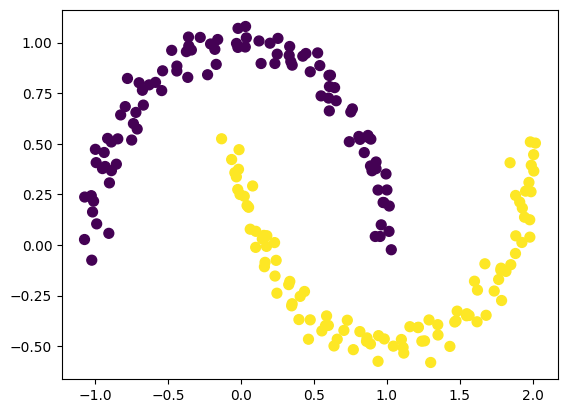

In [35]:
# Import the half moon function from sci-kit learn
from sklearn.datasets import make_moons

# Get access to points using the make_moons function
X_m, y_m = make_moons(200, noise=0.05, random_state=0)

# Plot the two half moon clusters
plt.scatter(X_m[:, 0], X_m[:, 1], c=y_m, s=50)

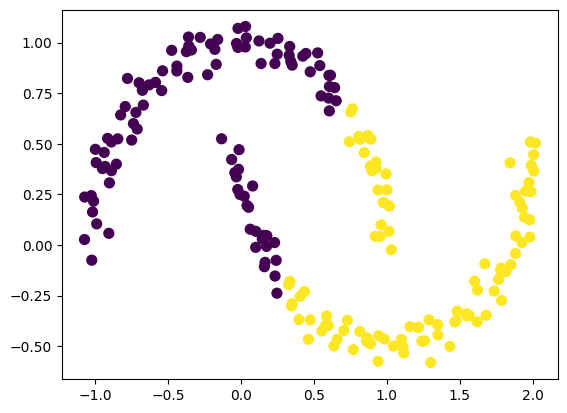

In [36]:
# Initialize K_Means object with k=2(for two half moons) and fit it to our data
kmm = KMeans(n_clusters=2, init='random', max_iter=10)
kmm.fit(X_m)

# Predict the classes for the data points
y_m_pred = kmm.predict(X_m)

# Plot the colored clusters as identified by K-Means
plt.scatter(X_m[:, 0], X_m[:, 1], c=y_m_pred, s=50)

# “We see that the k-means algorithm doesn't do a very good job of identifying the correct clusters. For clusters such as these half moons, another algorithm, called spectral clustering, with nearest-neighbor, affinity performs much better.”

/Users/matinatuladhar/.pyenv/versions/3.13.5/lib/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


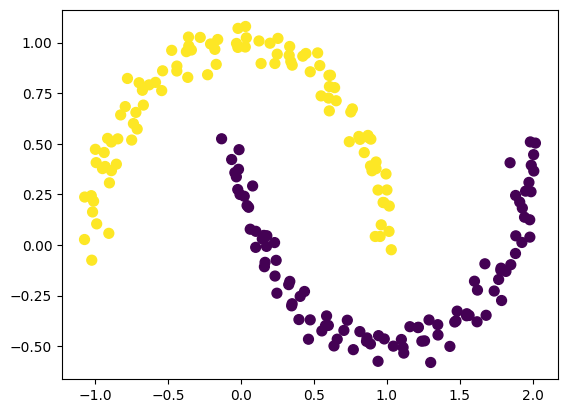

In [37]:
# Import Spectral Clustering from scikit learn
from sklearn.cluster import SpectralClustering

# Define the Spectral Clustering Model
model = SpectralClustering(n_clusters=2, affinity='nearest_neighbors')

# Fit and predict the labels
y_m_sc = model.fit_predict(X_m)

# Plot the colored clusters as identified by Spectral Clustering
plt.scatter(X_m[:, 0], X_m[:, 1], c=y_m_sc, s=50)

### “We see that spectral clustering does a very good job of identifying the half-moon clusters.”

### Spectral Clustering is a clustering algorithm that can detect non-linear clusters, like half-moons or concentric circles — something K-Means struggles with.


# Principal component analysis

### “Every principal component has more variance than every succeeding component and is orthogonal to the preceding component.”

In [41]:
import pandas as pd
# Load the Iris dataset into Pandas DataFrame
iris = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data",
                   names=['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'class'])

# Display the head of the dataframe
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [42]:
# Import Standard Scaler from scikit learn
from sklearn.preprocessing import StandardScaler

# Separate the features and the class
X = iris.drop('class', axis=1)
y = iris['class']

# Scale the features of X
X = pd.DataFrame(StandardScaler().fit_transform(X), columns=[
                 'sepal_length', 'sepal_width', 'petal_length', 'petal_width'])

X.head()

,sepal_length,sepal_width,petal_length,petal_width
0,-0.900681,1.032057,-1.341272,-1.312977
1,-1.143017,-0.124958,-1.341272,-1.312977
2,-1.385353,0.337848,-1.398138,-1.312977
3,-1.506521,0.106445,-1.284407,-1.312977
4,-1.021849,1.263460,-1.341272,-1.312977


In [43]:
# Import PCA
from sklearn.decomposition import PCA

# Initialize a PCA object to transform into the 2D Space
pca = PCA(n_components=2)

# Apply PCA
pca_iris = pca.fit_transform(X)
pca_iris = pd.DataFrame(data=pca_iris, columns=['PC1', 'PC2'])

pca_iris.head()

,PC1,PC2
0,-2.264542,0.505704
1,-2.086426,-0.655405
2,-2.367950,-0.318477
3,-2.304197,-0.575368
4,-2.388777,0.674767


In [45]:
pca.explained_variance_ratio_

array([0.72770452, 0.23030523])

### “We see that the first principal component holds about 72.8% of the information, whereas the second principal component holds about 23.3%. In total, 95.8% of the information is retained, whereas 4.2% of the information is lost in removing two dimensions. ”


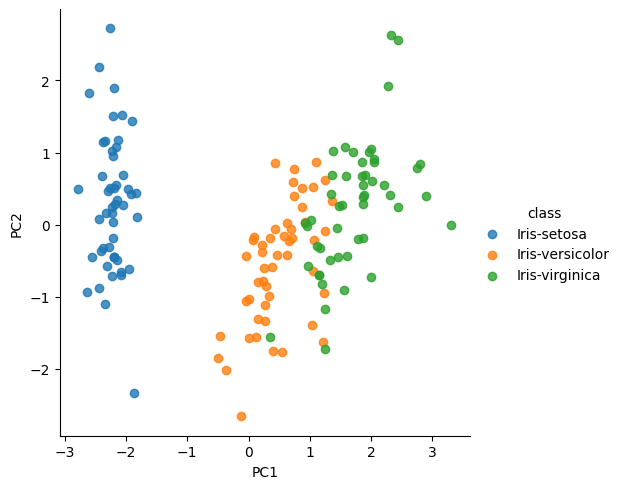

In [46]:
# Concatenate the class variable
pca_iris = pd.concat([pca_iris, y], axis=1)

# Display the scatterplot
sns.lmplot(x='PC1', y='PC2', data=pca_iris, hue='class', fit_reg=False)

# “Other dimensionality reduction techniques”


# 1. Linear-discriminant analysis (identify a set of n features that result in the maximum separation)

### “However, unlike PCA, which tries to retain the maximum information, LDA aims to identify a set of n features that result in the maximum separation (or discrimination) of classes. Since LDA requires labeled data in order to determine its components, it is a type of supervised learning 

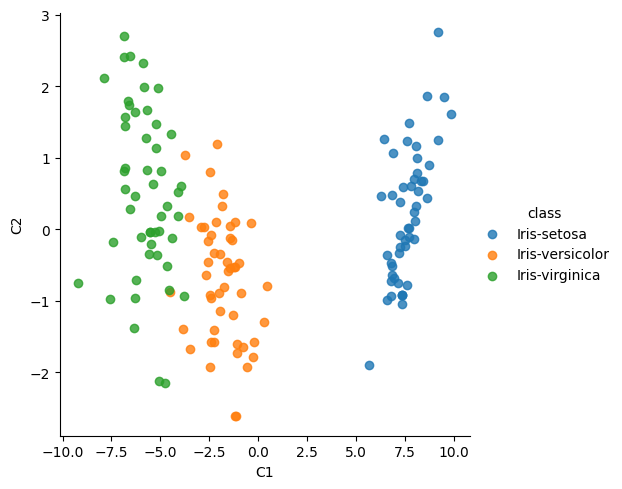

In [48]:
# Import LDA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Define the LDA object to have two components
lda = LinearDiscriminantAnalysis(n_components=2)

# Apply LDA
lda_iris = lda.fit_transform(X, y)
lda_iris = pd.DataFrame(data=lda_iris, columns=['C1', 'C2'])

# Concatenate the class variable
lda_iris = pd.concat([lda_iris, y], axis=1)

# Display the scatterplot
sns.lmplot(x='C1', y='C2', data=lda_iris, hue='class', fit_reg=False)

# 2. Singular value decomposition (high -> low dimension)

### “Singular value decomposition, or SVD, is a type of matrix analysis technique that allows us to represent a high-dimensional matrix in a lower dimension. SVD achieves this by identifying and removing the less important parts of the matrix and producing an approximation in the desired number of dimensions.

### thulo matrix lai sano matrix ma divide garcha , lastai thulo matrix huncha teslai 3 matrices ma divide gardincha while focusing on more important parts

# ________________________________________________________________________

# Supervised Learning

### a class of machine learning algorithm that takes in a series of vectors and their corresponding output (a continuous value or a class) as input, and produces an inferred function that can be used to map new examples.

### important precondition = availability of labeled data

## Types of supervised learning:

### 1. Classification (discrete set of values as target variable like like and dislike)

### 2. Regression (continuous value as target like average rating between one and five)

In [49]:
# Divide the dataset into the feature dataframe and the target class series
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
X, y = iris.drop('class', axis=1), iris['class']

# Split data into test and train dataset
# We will train on 75% of data and assess/test our performance on 25% of data

# Import splitting function

# Split data into training and test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0)

# Import the Gradient Boosting Classifier

# Appky Gradient Boosting to the training data
gbc = GradientBoostingClassifier()
gbc.fit(X_train, y_train)

# Compute the accuracy on the test set
gbc.score(X_test, y_test)

0.9736842105263158

### We see that the classifier achieves a 97.3% accuracy on the unseen test data. Like random forests, gradient boosting machines are able to gauge the predictive power of each feature. Let's plot the feature importances of the Iris dataset:



<Axes: >

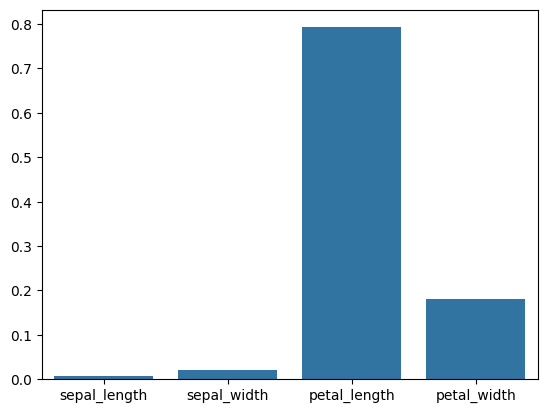

In [50]:
# Display a bar plot of feature importances
sns.barplot(x=['sepal_length', 'sepal_width', 'petal_length',
            'petal_width'], y=gbc.feature_importances_)